In [1]:
import copy
import torch
import numpy as np
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from graph_datasets import GraphDataset
from graph_attention import CrossAttention
from performer_pytorch import NaiveAttention, FastAttention

/home/x_aidda/.conda/envs/berst/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/x_aidda/.conda/envs/berst/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/x_aidda/.conda/envs/berst/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:504: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you wan

In [2]:
edge_index = torch.tensor([[0,1],
                           [1,0],
                           [1,2],
                           [2,1]], dtype=torch.long)

n_nodes = 3
n_tokens = 10
token_dim = 6
x = torch.tensor(np.random.uniform(0,1,size=(n_nodes, n_tokens, token_dim)), dtype=torch.float)
graph = Data(x=x, edge_index=edge_index.t().contiguous())

data = GraphDataset([graph])
loader = DataLoader(data, batch_size=1)

In [3]:
gca = CrossAttention(dim=token_dim, heads=2, dim_head=16, fast_attention=True)

In [4]:
batch = next(iter(loader))
out, attn = gca(batch.x, batch.edge_index, output_attentions=True)

print(out.shape)
print(attn.shape)

out2 = gca(batch.x, batch.edge_index)

assert(torch.equal(out, out2))

out

torch.Size([3, 10, 6])
torch.Size([3, 10, 10])


tensor([[[-0.2787,  0.0475, -0.0608,  0.1219, -0.0859, -0.1556],
         [-0.2809,  0.0445, -0.0600,  0.1220, -0.0839, -0.1510],
         [-0.2822,  0.0451, -0.0615,  0.1237, -0.0857, -0.1524],
         [-0.2805,  0.0438, -0.0613,  0.1232, -0.0850, -0.1518],
         [-0.2822,  0.0444, -0.0622,  0.1233, -0.0866, -0.1519],
         [-0.2783,  0.0470, -0.0588,  0.1204, -0.0829, -0.1539],
         [-0.2798,  0.0474, -0.0595,  0.1223, -0.0842, -0.1542],
         [-0.2802,  0.0479, -0.0604,  0.1228, -0.0862, -0.1547],
         [-0.2812,  0.0452, -0.0590,  0.1217, -0.0829, -0.1507],
         [-0.2809,  0.0459, -0.0601,  0.1225, -0.0853, -0.1521]],

        [[-0.3071,  0.0636, -0.0645,  0.1725, -0.1085, -0.1625],
         [-0.3078,  0.0650, -0.0646,  0.1720, -0.1093, -0.1613],
         [-0.3039,  0.0673, -0.0601,  0.1721, -0.1062, -0.1685],
         [-0.3064,  0.0652, -0.0638,  0.1719, -0.1084, -0.1634],
         [-0.3052,  0.0682, -0.0620,  0.1722, -0.1078, -0.1660],
         [-0.3083,  0.0

In [5]:
attn.shape

torch.Size([3, 10, 10])

### To verify that cross-attention is working:
- Three nodes configured in a line:  {0}--{1}--{2}
- Manually compute K, Q, V matrices for each node
- Assert:
  - H_0 = Attention(Q_0, K_1, V_1)
  - H_1 = (Attention(Q_1, K_0, V_0) + Attention(Q_1, K_2, V_2)) / 2
  - H_2 = Attention(Q_2, K_1, V_1)

In [6]:
n_nodes = 3
n_tokens = 4
token_dim = 2

edge_index = torch.tensor([[0,1],
                           [1,0],
                           [1,2],
                           [2,1]], dtype=torch.long)

x = torch.tensor([[[0,1],
                   [1,1],
                   [1,0],
                   [0,1]],
                  [[-1,-1],
                   [0,-2],
                   [-1,0],
                   [-.5,-.5]],
                  [[.4,.4],
                   [.2,.2],
                   [.1,.1],
                   [.1,.4]]])
graph = Data(x=x, edge_index=edge_index.t().contiguous())

data = GraphDataset([graph])
loader = DataLoader(data, batch_size=1)

In [7]:
gca = CrossAttention(dim=token_dim, heads=1, dim_head=2, fast_attention=False)
gca.eval()

CrossAttention()

In [8]:
batch = next(iter(loader))
out, attn_wts = gca(batch.x, batch.edge_index, output_attentions=True)
out

tensor([[[-0.5770, -0.4498],
         [-0.5984, -0.4497],
         [-0.5966, -0.4497],
         [-0.5770, -0.4498]],

        [[-0.7285, -0.6095],
         [-0.7303, -0.6112],
         [-0.7288, -0.6095],
         [-0.7297, -0.6104]],

        [[-0.5846, -0.4498],
         [-0.5799, -0.4498],
         [-0.5775, -0.4499],
         [-0.5780, -0.4498]]], grad_fn=<AddBackward0>)

In [9]:
attn_wts.shape

torch.Size([3, 4, 4])

In [10]:
attention = NaiveAttention()

q0, q1, q2 = gca.to_q(x[0]), gca.to_q(x[1]), gca.to_q(x[2])
k0, k1, k2 = gca.to_k(x[0]), gca.to_k(x[1]), gca.to_k(x[2])
v0, v1, v2 = gca.to_v(x[0]), gca.to_v(x[1]), gca.to_v(x[2])

a0 = attention(q0, k1, v1)
a1 = (attention(q1, k0, v0) + attention(q1, k2, v2)) / 2
a2 = attention(q2, k1, v1)

assert torch.equal(gca.to_out(a0), out[0])
assert torch.equal(gca.to_out(a1), out[1])
assert torch.equal(gca.to_out(a2), out[2])

### Test attention routing through a GraphSequence

In [11]:
import seaborn as sns
from graph_attention import GraphPerformer
from matplotlib import pyplot as plt

In [12]:
edge_index = torch.tensor([[0,1],
                           [1,0],
                           [1,2],
                           [2,1]], dtype=torch.long)

n_nodes = 3
n_tokens = 10
token_dim = 6
x = torch.tensor(np.random.uniform(0,1,size=(n_nodes, n_tokens, token_dim)), dtype=torch.float)
graph = Data(x=x, edge_index=edge_index.t().contiguous())

data = GraphDataset([graph])
loader = DataLoader(data, batch_size=1)

In [13]:
gp = GraphPerformer(
    dim=token_dim,
    depth=6,       # number of attention layers (pairs of Self, Cross)
    heads=2,
    dim_head=16)

batch = next(iter(loader))
out, attn = gp(batch.x, batch.edge_index, output_attentions=True)

In [14]:
print(attn.shape)

avg_self = attn[0].mean(axis=0)
avg_cross = attn[1].mean(axis=0)

torch.Size([2, 3, 10, 10])


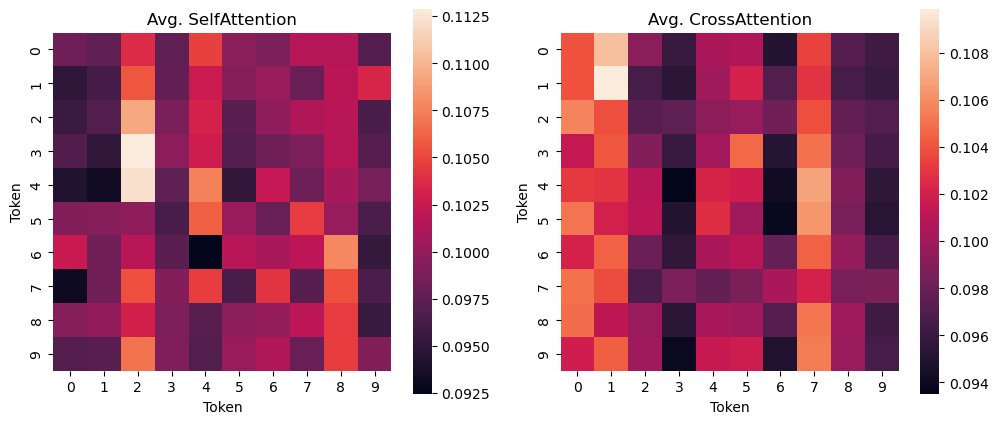

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))
sns.heatmap(avg_self.detach().numpy(), ax=ax[0])
ax[0].set_title('Avg. SelfAttention')
sns.heatmap(avg_cross.detach().numpy(), ax=ax[1])
ax[1].set_title('Avg. CrossAttention')

for i in range(2):
    ax[i].set_aspect('equal')
    ax[i].set_ylabel('Token')
    ax[i].set_xlabel('Token')

plt.show()

In [16]:
avg_cross

tensor([[0.1040, 0.1079, 0.0992, 0.0960, 0.1004, 0.1006, 0.0951, 0.1034, 0.0972,
         0.0962],
        [0.1039, 0.1098, 0.0965, 0.0954, 0.0999, 0.1021, 0.0970, 0.1029, 0.0966,
         0.0960],
        [0.1057, 0.1038, 0.0972, 0.0975, 0.0993, 0.0997, 0.0982, 0.1038, 0.0977,
         0.0971],
        [0.1014, 0.1040, 0.0989, 0.0960, 0.1002, 0.1047, 0.0951, 0.1050, 0.0981,
         0.0965],
        [0.1031, 0.1029, 0.1009, 0.0935, 0.1022, 0.1019, 0.0942, 0.1069, 0.0989,
         0.0955],
        [0.1051, 0.1020, 0.1011, 0.0951, 0.1027, 0.1000, 0.0939, 0.1063, 0.0985,
         0.0953],
        [0.1021, 0.1045, 0.0980, 0.0957, 0.1004, 0.1010, 0.0977, 0.1044, 0.0996,
         0.0965],
        [0.1049, 0.1038, 0.0967, 0.0987, 0.0976, 0.0986, 0.1004, 0.1021, 0.0985,
         0.0986],
        [0.1049, 0.1012, 0.0998, 0.0954, 0.1003, 0.1000, 0.0972, 0.1051, 0.1000,
         0.0962],
        [0.1019, 0.1043, 0.1000, 0.0939, 0.1015, 0.1018, 0.0949, 0.1053, 0.0998,
         0.0965]], grad_fn=<